# Würfelspiel

Im Würfelspiel Ratte muss man gleichzeitig mit 9 Würfel würfeln und Punkte erzielen. Die größte Punkte-bringende Konstellation an Würfeln ist die Ratte, eine Straße von 1-6.

- Erstellen Sie $N = 10^4$ Würfelergebnisse mit `numpy.random.choice(<Liste möglicher Werte>, size=(<#Werte>, <#Würfel>))` 
- Bestimmen Sie die Wahrscheinlichkeit eine Ratte zu Würfel mit 9, 8, 7 und 6 Würfeln.

Tipps:
- `numpy.unique()` gibt ein Array mit allen Einzigartigen Elementen zurück
- `len()` gibt die Länge eines Arrays zurück




In [3]:
import numpy as np
import matplotlib.pyplot as plt

n = 10**4

Würfel = np.random.choice([1,2,3,4,5,6], size = (n, 9))
würfelunique = np.unique(Würfel[1])
ElementeInWurf = len(würfelunique)

counter = 0
for games in Würfel:
    if (len(np.unique(games))==6):
        counter +=1
print(counter/n)

0.1864


# Coupon Collectors Problem

Ein Sammelkartenspiel besteht aus insgesamt r unterschiedlichen Karten.

Beim Kauf eines Kartenpacks erhält man k unterschiedliche Karten.
Jede gezogene Karte ist unabhängig und mit gleicher Wahrscheinlichkeit eine der r Karten.

Ein Spieler kauft so lange Kartenpacks, bis er alle r Karten mindestens einmal besitzt.

- Erstellen Sie $N=10^4$ zufällige Kartenpacks-Ziehungen mit
  - r = 50 verschiedene Karten
  - k = 5 Karten pro Pack
- Bestimmen Sie die durchschnittliche Anzahl von gekauften Kartenpacks.
- Plotten Sie ein Histogramm der benötigten Packs.
- Bestimmen Sie die Wahrscheinlichkeit, dass mehr als 30 Packs benötigt werden
- Zusatz: Bestimmen Sie die durchschnittliche Anzahl von gekauften Kartenpacks, wenn in einem Kartenpacks die gleichen Karten enthalten sein können. 

COUPON COLLECTOR'S PROBLEM - Karten verschieden pro Pack
Durchschnittliche Anzahl gekaufter Packs: 43.70
Median: 42.00
Standardabweichung: 11.93
Minimum: 20
Maximum: 142

Wahrscheinlichkeit > 30 Packs: 0.9026 (90.26%)



<Axes: ylabel='Count'>

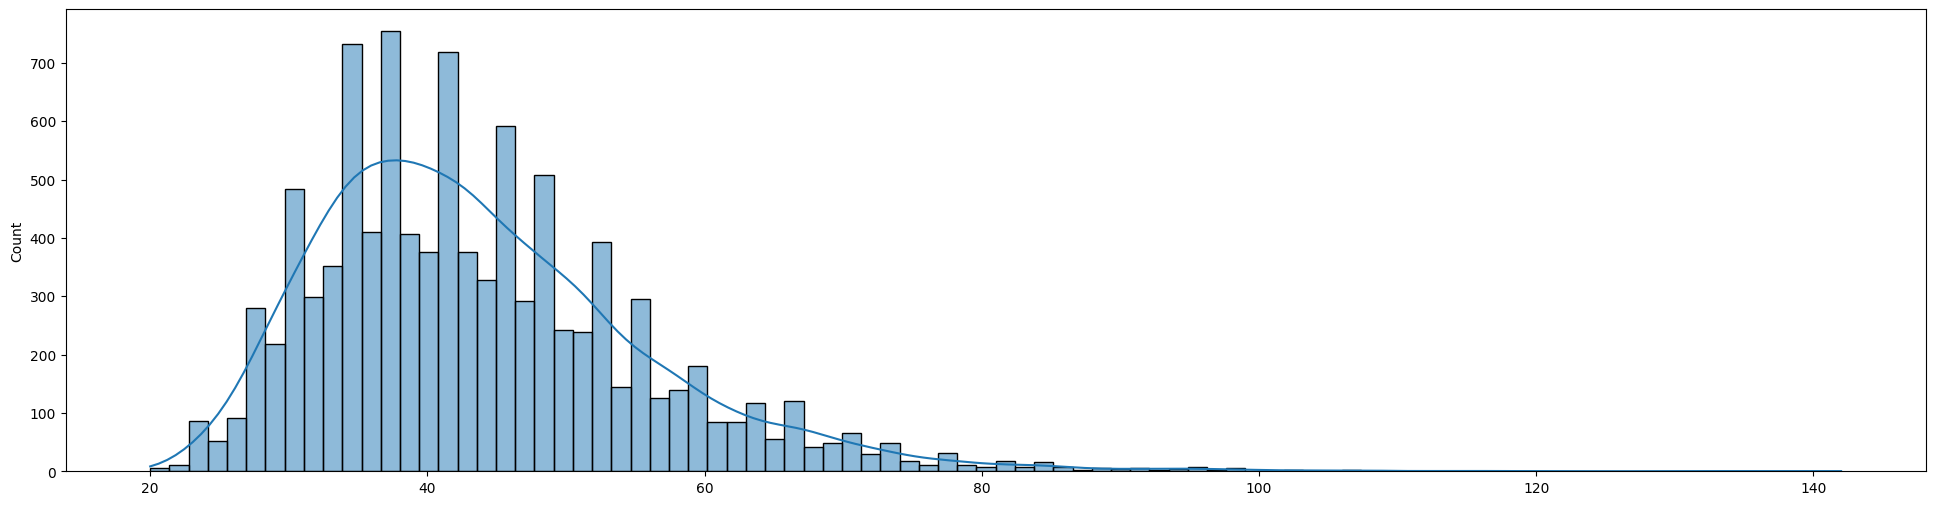

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn

# Parameter
N = 10**4  # Anzahl der Simulationen
r = 50     # Anzahl verschiedener Karten
k = 5      # Karten pro Pack

# Simulation 1: Karten können sich NICHT in einem Pack wiederholen
packs_needed = []

for _ in range(N):
    collected_cards = set()
    packs = 0
    
    while len(collected_cards) < r:
        pack = np.random.choice(r, size=k, replace=False)
        collected_cards.update(pack)
        packs += 1
    packs_needed.append(packs)
packs_needed = np.array(packs_needed)
print("=" * 60)
print("COUPON COLLECTOR'S PROBLEM - Karten verschieden pro Pack")
print("=" * 60)
print(f"Durchschnittliche Anzahl gekaufter Packs: {np.mean(packs_needed):.2f}")
print(f"Median: {np.median(packs_needed):.2f}")
print(f"Standardabweichung: {np.std(packs_needed):.2f}")
print(f"Minimum: {np.min(packs_needed)}")
print(f"Maximum: {np.max(packs_needed)}")
print()

# Wahrscheinlichkeit dass mehr als 30 Packs benötigt werden
prob_more_than_30 = np.mean(packs_needed > 30)
print(f"Wahrscheinlichkeit > 30 Packs: {prob_more_than_30:.4f} ({prob_more_than_30*100:.2f}%)")
print()
plt.figure(figsize=(24, 6))
sn.histplot(packs_needed, kde=True)





# Bauteillager

In einem Bauteillager befinden sich drei unterschiedliche Widerstandswerte. Zu 55% ist das Lager mit 1k Ohm, zu 30% mit 10k Ohm und der Rest mit 100k Ohm Widerstände gefüllt.
Für eine Qualitätskontrolle wird zunächst ein Widerstand zufällig aus dem Lager ausgewählt.

- Erstellen Sie $N=10^4$ zufällige Ziehungen mit `numpy.random.choice(<values>, size=<#Werte>, p=<Wahrscheinlichkeiten>)`.
- Wie groß ist die Wahrscheinlichkeit einen Widerstand größer als 5k Ohm auszuwählen?
- Bestimmen sie den mittleren Widerstandswert
- Plotten Sie ein Häufigkeit der Widerstandswerte in einem Balkendiagramm oder Histogramm.

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Monte-Carlo Bestimmung von $\pi$
Gegeben ist ein Quadrat mit Seitenlänge 2 und ein darin einbeschriebener Einheitskreis.

Schätzen Sie $\pi$ mithilfe einer Monte-Carlo-Simulation.


- Erzeugen Sie $N = 10^4$ gleichverteilte Zufallspunkte im Bereich $[-1,1] [-1,1]$ mit `numpy.random.uniform()`.
- Bestimmen Sie den Anteil der Punkte innerhalb des Kreises und damit näherungsweise die Zahl $\pi$.
- Visualisieren Sie die Punkte (Treffer/Nicht-Treffer).
- Untersuchen Sie den Fehler für $N = 10^2$ bis $10^6$ mit `np.pi`.

3.14133512


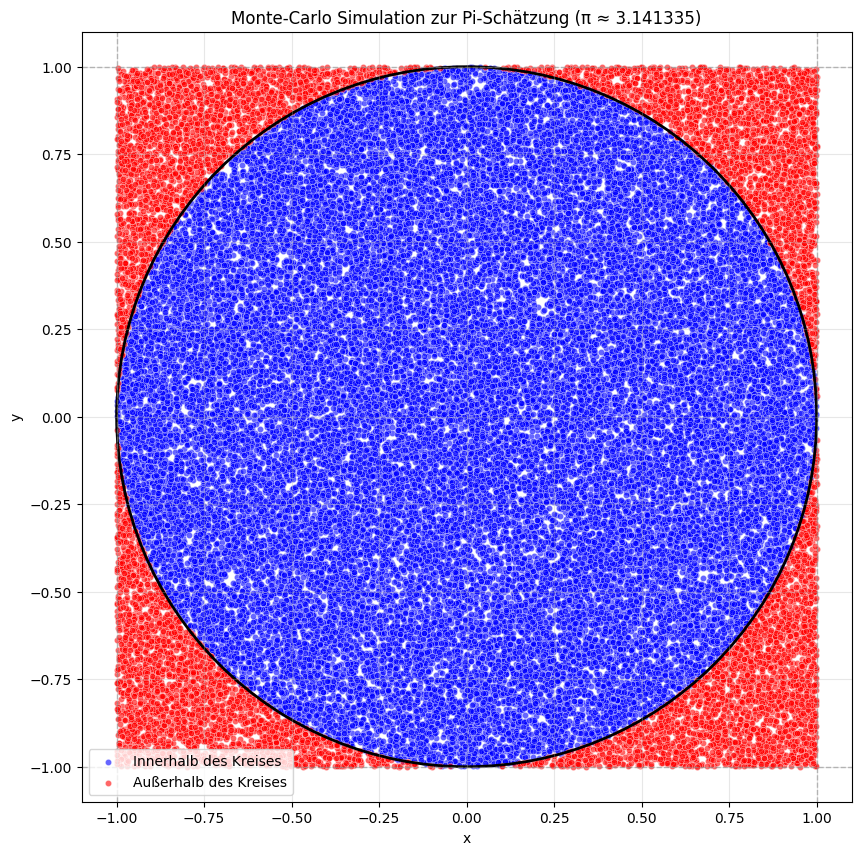

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Circle

n = 10**8

x = np.random.uniform(-1, 1, size=n)
y = np.random.uniform(-1, 1, size=n)

inside_circle = x**2 + y**2 <= 1

pi_est = 4 * inside_circle.sum() / n
print(pi_est)

# Scatterplot mit Seaborn erstellen (mit Stichprobe für bessere Visualisierung)
sample_size = 50000
sample_indices = np.random.choice(n, sample_size, replace=False)

x_sample = x[sample_indices]
y_sample = y[sample_indices]
inside_sample = inside_circle[sample_indices]

plt.figure(figsize=(10, 10))

# Scatterplot: Punkte innerhalb und außerhalb des Kreises in unterschiedlichen Farben
sns.scatterplot(x=x_sample[inside_sample], y=y_sample[inside_sample], 
                label='Innerhalb des Kreises', s=20, alpha=0.6, color='blue')
sns.scatterplot(x=x_sample[~inside_sample], y=y_sample[~inside_sample], 
                label='Außerhalb des Kreises', s=20, alpha=0.6, color='red')

# Kreis zeichnen
circle = Circle((0, 0), 1, fill=False, edgecolor='black', linewidth=2)
plt.gca().add_patch(circle)

# Quadrat (Grenzen)
plt.axhline(y=1, color='gray', linestyle='--', linewidth=1, alpha=0.5)
plt.axhline(y=-1, color='gray', linestyle='--', linewidth=1, alpha=0.5)
plt.axvline(x=1, color='gray', linestyle='--', linewidth=1, alpha=0.5)
plt.axvline(x=-1, color='gray', linestyle='--', linewidth=1, alpha=0.5)

plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)
plt.gca().set_aspect('equal')
plt.xlabel('x')
plt.ylabel('y')
plt.title(f'Monte-Carlo Simulation zur Pi-Schätzung (π ≈ {pi_est:.6f})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Käfer auf der Uhr
Ein Käfer sitzt auf der Zahl 12 eines Ziffernblattes. Er bewegt sich mit jedem Schritt mit gleicher Wahrscheinlichkeit nach rechts oder nach links (Beispiel nach Schritt 1 ist der Käfer entweder auf der 11 oder auf der 1). Nachdem er jede Zahl von 1 bis 11 mindestens einmal besucht hat stoppt er. 

- Wie groß ist Wahrscheinlichkeit, dass der Käfer auf der Zahl 6 stoppt (d.h. die 6 ist die letzte Zahl auf der er landet)?
- Wie ändert sich die Wahrscheinlichkeit, wenn die Chance 45% ist gegen den Uhrzeigersinn und 55% mit dem Uhrzeigersinn zu gehen?

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Monte-Carlo-Integration einer Kurve
Bestimmen Sie die Fläche unter der Kurve

$$f(x) = e^{-x^2}$$

im Bereich

$$x \in [-2,2]$$

- Plotten sie die Funktion im Bereich [-2, 2]
- Verwenden Sie eine Monte-Carlo-Integration.
  - Zur Generierung der Zufallspunkte verwenden Sie `numpy.random.uniform` mit dem angegebenen Definitionsbereich.
- Visualisieren Sie Punkte unter und über der Kurve.
- Vergleichen Sie mit `numpy.trapz()`.

/tmp/ipykernel_115879/3039001776.py:74: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


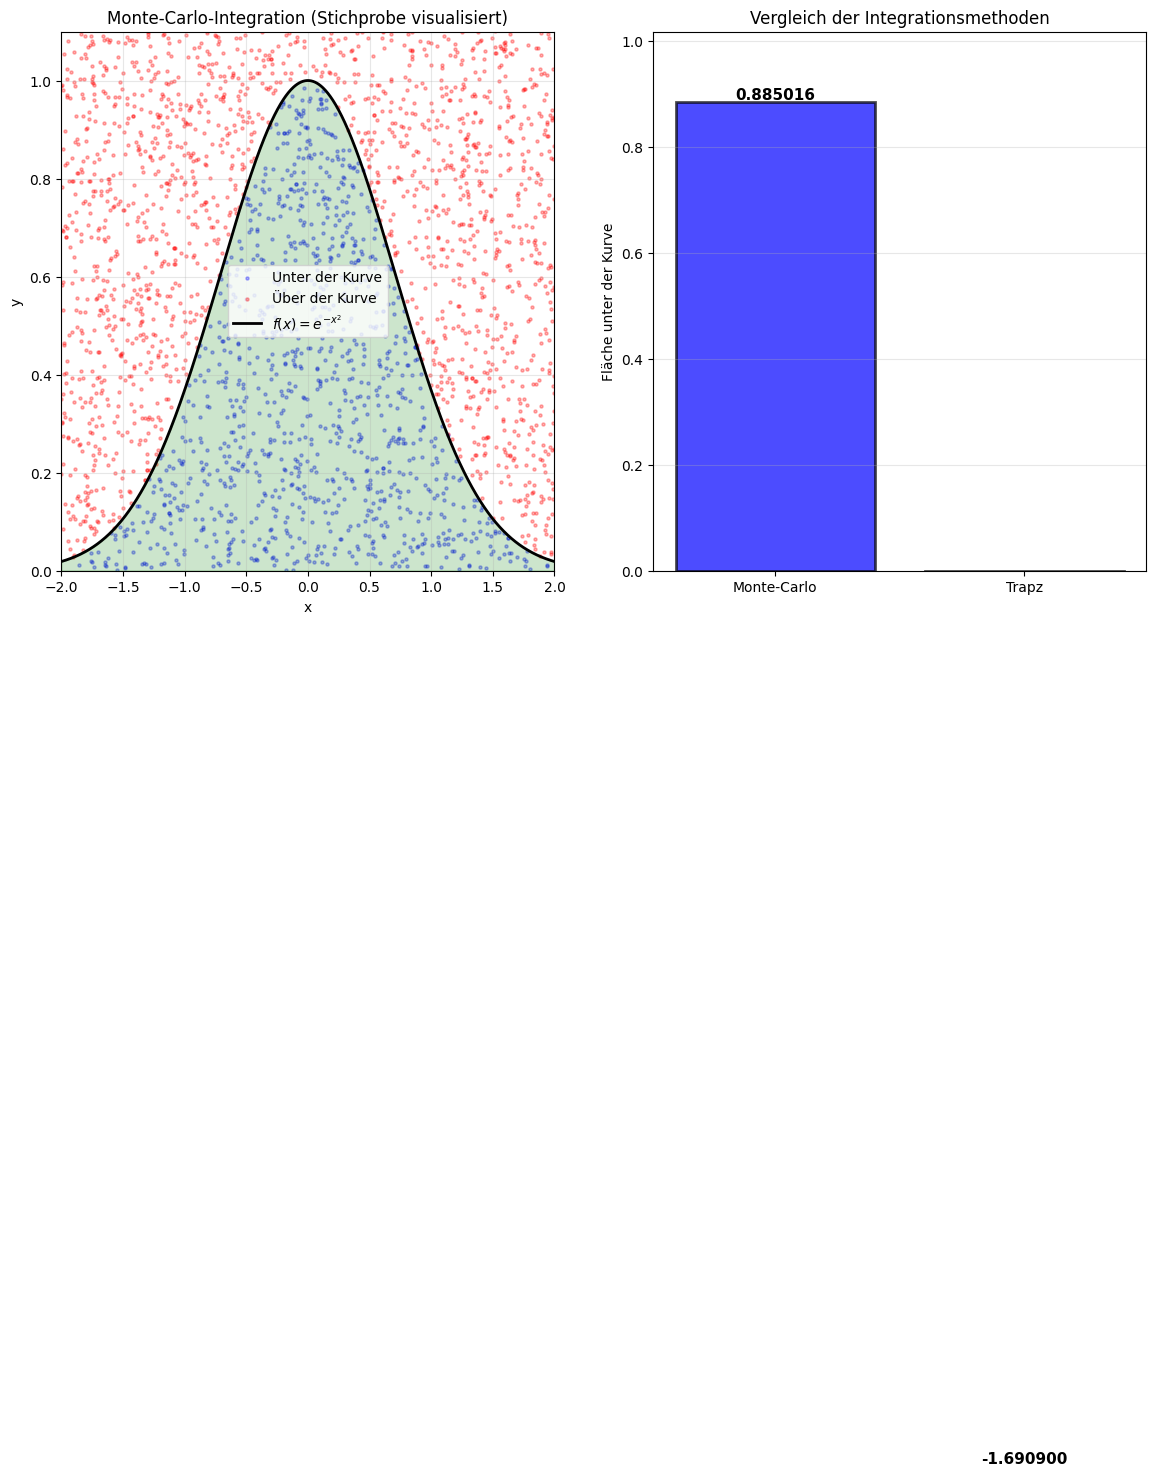

Monte-Carlo Integration (n=1,000,000): 0.88501600
Trapez-Integration: -1.69090003
Differenz: 2.57591603


In [23]:
import numpy as np
import matplotlib.pyplot as plt

# Funktion definieren
def f(x):
    return np.exp(-x**2)

# Parameter für Visualisierung und Integration
x_line = np.linspace(-2, 2, 1000)
y_line = f(x_line)

# Monte-Carlo-Integration
n = 10**6
x_random = np.random.uniform(-2, 2, size=n)
y_random = np.random.uniform(0, 2, size=n)

# Bestimme, welche Punkte unter der Kurve liegen
f_values = f(x_random)
under_curve = y_random <= f_values

# Monte-Carlo Schätzung der Fläche
# Fläche des Rechtecks = breite * höhe = 4 * 1 = 4
area_rectangle = 4 * 1
proportion_under = under_curve.sum() / n
area_mc = area_rectangle * proportion_under

# Trapez-Integration zum Vergleich
area_trapz =np.trapezoid(x_line, y_line)

# Visualisierung
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# Linkes Plot: Kurve + Sample für die Integration
ax = axes[0]
sample_size_plot = 5000
sample_indices = np.random.choice(n, sample_size_plot, replace=False)

ax.scatter(x_random[sample_indices][under_curve[sample_indices]], 
           y_random[sample_indices][under_curve[sample_indices]],
           alpha=0.3, s=5, c='blue', label='Unter der Kurve')
ax.scatter(x_random[sample_indices][~under_curve[sample_indices]], 
           y_random[sample_indices][~under_curve[sample_indices]],
           alpha=0.3, s=5, c='red', label='Über der Kurve')

ax.plot(x_line, y_line, 'black', linewidth=2, label=r'$f(x) = e^{-x^2}$')
ax.fill_between(x_line, 0, y_line, alpha=0.2, color='green')
ax.set_xlim(-2, 2)
ax.set_ylim(0, 1.1)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Monte-Carlo-Integration (Stichprobe visualisiert)')
ax.legend()
ax.grid(True, alpha=0.3)

# Rechtes Plot: Vergleich der Methoden
ax = axes[1]
methods = ['Monte-Carlo', 'Trapz']
areas = [area_mc, area_trapz]
colors = ['blue', 'orange']

bars = ax.bar(methods, areas, color=colors, alpha=0.7, edgecolor='black', linewidth=2)

for bar, area in zip(bars, areas):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{area:.6f}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylabel('Fläche unter der Kurve')
ax.set_title('Vergleich der Integrationsmethoden')
ax.set_ylim(0, max(areas) * 1.15)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Ausgabe der Ergebnisse
print(f"Monte-Carlo Integration (n={n:,}): {area_mc:.8f}")
print(f"Trapez-Integration: {area_trapz:.8f}")
print(f"Differenz: {abs(area_mc - area_trapz):.8f}")